In [1]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Import everything from your environment and script
from OLD_qopt_funcs import *
from network_funcs import *
from Energy_qkd import *

# --- STYLING SETUP ---
# Create directory for saving plots
os.makedirs('plots', exist_ok=True)

# Seaborn styling: white background, no grid, clean ticks
sns.set_theme(style="white", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.bottom": True,
    "ytick.left": True,
    "figure.autolayout": True
})

# Define a strict color palette for consistency across all graphs
COLOR_CV = '#4C72B0'     # Blue
COLOR_DV = '#C44E52'     # Red
COLOR_HYBRID = '#8172B2' # Purple
COLOR_MAP = {'CV': COLOR_CV, 'DV': COLOR_DV, 'hybrid': COLOR_HYBRID}

print("Environment setup complete. Plots will be saved to the '/plots' directory.")

Calculating crossover distance...
92.84550858707846
354.822880520985
Optimal hybrid crossover distance found: 91.13 km
Pre-computing key rates...
Environment setup complete. Plots will be saved to the '/plots' directory.


## Plot 1: CV-DV Crossover

In [2]:
print(d_c_DV)

354.822880520985


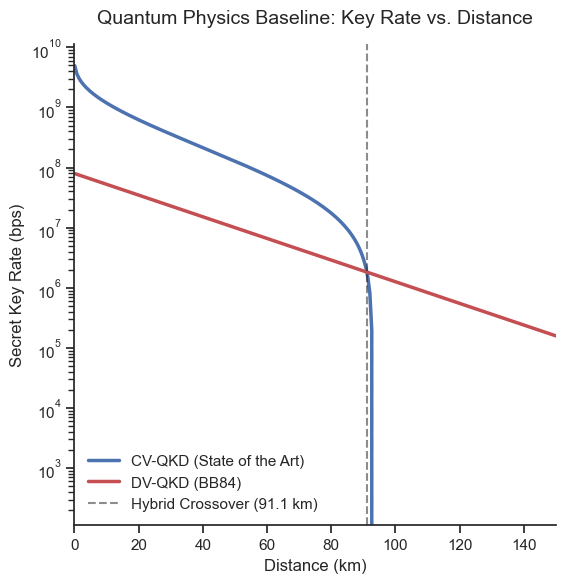

In [2]:
# Create an array of distances (km)
d_plot = np.linspace(0.1, 300, 500)
rate_cv_plot = [func_CV(d) for d in d_plot]
rate_dv_plot = [func_DV(d) for d in d_plot]

fig, ax = plt.subplots(figsize=(6, 6))

# Plot the physics
ax.plot(d_plot, rate_cv_plot, color=COLOR_CV, label='CV-QKD (State of the Art)', linewidth=2.5)
ax.plot(d_plot, rate_dv_plot, color=COLOR_DV, label='DV-QKD (BB84)', linewidth=2.5)
ax.axvline(d_hybrid, color='k', linestyle='--', alpha=0.5, label=f'Hybrid Crossover ({d_hybrid:.1f} km)')

# Formatting
ax.set_yscale('log')
ax.set_xlim(0, 150)
#ax.set_ylim(1, 10**8)
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Secret Key Rate (bps)', fontsize=12)
ax.set_title('Quantum Physics Baseline: Key Rate vs. Distance', fontsize=14, pad=15)
ax.legend(frameon=False)
ax.set_box_aspect(1) # Forces the plot area to be perfectly square

plt.savefig('plots/1_physics_baseline.pdf', bbox_inches='tight')
plt.show()

## Plot 2: Node Classification & Kamada-Kawai Visualization

C:\Users\ebirch\AppData\Local\Temp\ipykernel_5572\3832339681.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette=COLOR_MAP, ax=ax)


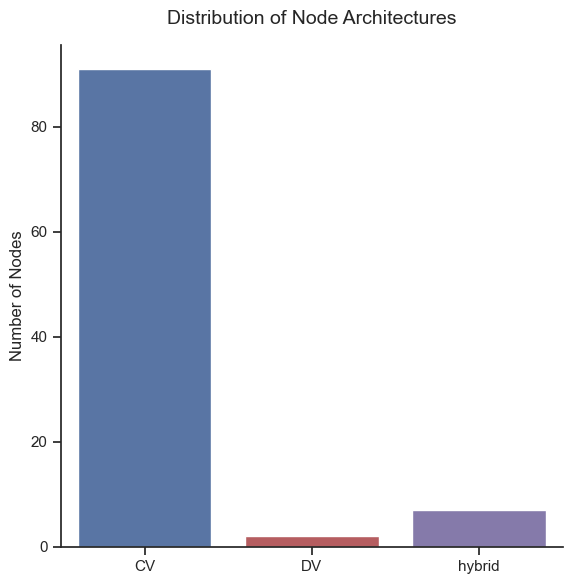

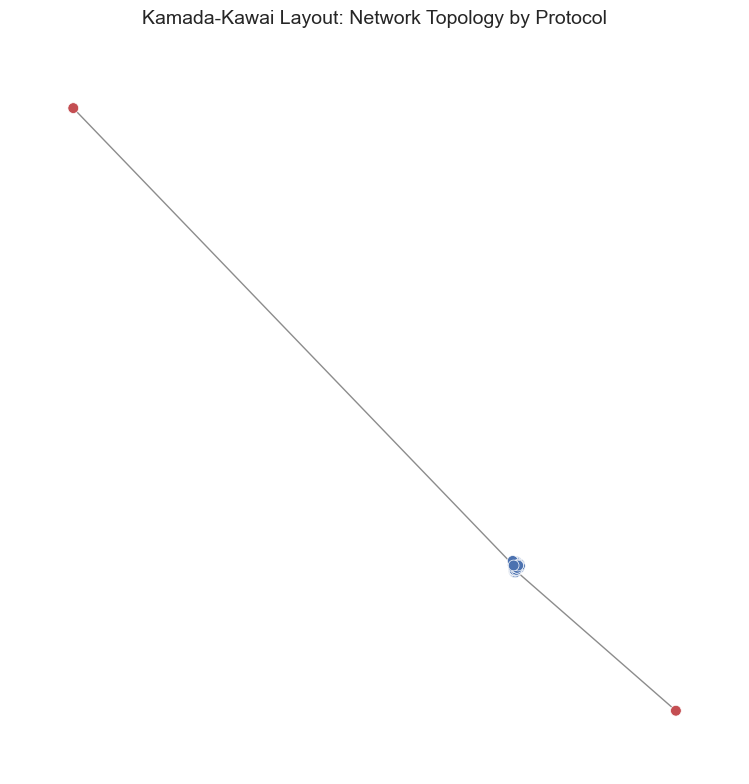

In [3]:
# 1. Generate a sample pruned graph
A, Dists = S2_graph_definite_N(N=100, beta=2.6261, mu=0.0233, return_coords=False)
W, edge_CV, edge_DV = np.zeros_like(A), np.zeros_like(A), np.zeros_like(A)

for i in range(100):
    for j in range(i):
        if A[i, j] == 1:
            dij = 45 * Dists[i, j]
            idx_d = np.argmin(abs(dij - d_set))
            h_rate = keyrates[idx_d]
            if dij < d_c_DV and h_rate > rate_min:
                W[i, j] = W[j, i] = h_rate ** -1
                if dij >= d_hybrid: edge_DV[i, j] = edge_DV[j, i] = True
                else: edge_CV[i, j] = edge_CV[j, i] = True

G_sample = nx.from_numpy_array(W)

# 2. Classify nodes
# Inside your loops, update the call to this:
node_classes = [classifiying_node(G_sample, n, edge_CV, edge_DV) for n in G_sample.nodes()]
class_counts = {'CV': node_classes.count('CV'), 'DV': node_classes.count('DV'), 'hybrid': node_classes.count('hybrid')}

# --- PLOT 3A: HISTOGRAM ---
fig, ax = plt.subplots(figsize=(6, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette=COLOR_MAP, ax=ax)
ax.set_ylabel('Number of Nodes')
ax.set_title('Distribution of Node Architectures', fontsize=14, pad=15)
ax.set_box_aspect(1)
plt.savefig('plots/2a_node_histogram.pdf', bbox_inches='tight')
plt.show()

# --- PLOT 3B: KAMADA-KAWAI NETWORK GRAPH ---
fig, ax = plt.subplots(figsize=(8, 8))
pos = nx.kamada_kawai_layout(G_sample)
node_colors = [COLOR_MAP[cls] for cls in node_classes]

nx.draw_networkx_nodes(G_sample, pos, node_color=node_colors, node_size=60, edgecolors='white', linewidths=0.5, ax=ax)
nx.draw_networkx_edges(G_sample, pos, alpha=0.5, ax=ax)
ax.set_title('Kamada-Kawai Layout: Network Topology by Protocol', fontsize=14, pad=15)
ax.axis('off')
ax.set_box_aspect(1)
plt.savefig('plots/2b_network_topology.pdf', bbox_inches='tight')
plt.show()

## Plot 3: Topological Variance

Running 20 network simulations (N=500) for variance analysis...

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 1,514,282 W | SKR: 1,315,152.07 bps | EE: 0.86849866 bits/J | REACH: 99.60 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 1,514,282 W | Avg SKR: 1,315,152.07 bps | Avg EE: 0.86849866 bits/J | AVG REACH: 99.60 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 1,452,793 W | SKR: 918,769.77 bps | EE: 0.63241616 bits/J | REACH: 99.60 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 1,452,793 W | Avg SKR: 918,769.77 bps | Avg EE: 0.63241616 bits/J | AVG REACH: 99.60 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 1,480,750 W | SKR: 1,393,073.32 bps | EE: 0.94078926 bits/J | REACH: 99.20 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 1,480,750 W | Avg SKR: 1,393,073.32 bps | Avg EE: 0.94078926 bits/J | AVG REACH: 99.20 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique 

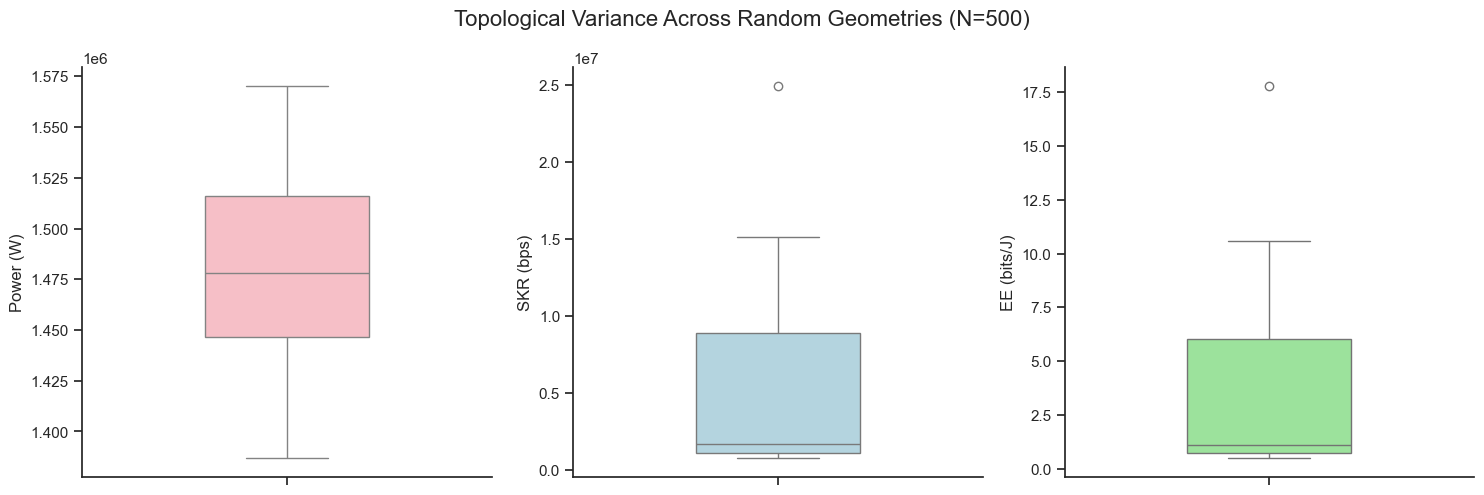


--- LaTeX Code for Variance Table ---
\begin{tabular}{lrrrr}
\toprule
Metric & Mean & Std Dev & Min & Max \\
\midrule
Power (W) & 1476988.48 & 49736.88 & 1386906.40 & 1570399.80 \\
SKR (bps) & 5602925.98 & 6687797.28 & 768685.88 & 24936373.03 \\
EE (bits/J) & 3.85 & 4.69 & 0.51 & 17.80 \\
\bottomrule
\end{tabular}



In [4]:
# Collect data over multiple network generations
runs = 20 # 20 runs is plenty for a boxplot
var_data = []

N_val = 500
rho_val = 1.5e-3
radius_val = np.sqrt(N_val / (4 * np.pi * rho_val))

print(f"Running {runs} network simulations (N={N_val}) for variance analysis...")
for _ in range(runs):
    # Assuming network_energy_efficiency is adapted to take N and radius
    _, skrs, ees, pwr, skr, ee, _ = network_energy_efficiency(num_runs=1, N=N_val, radius=radius_val, routing_mode='serial')
    var_data.append({'Power (W)': pwr, 'SKR (bps)': skr, 'EE (bits/J)': ee})

df_var = pd.DataFrame(var_data)

# --- PLOT 4: VARIANCE BOXPLOTS ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df_var['Power (W)'], ax=axes[0], color='lightpink', width=0.4)
sns.boxplot(y=df_var['SKR (bps)'], ax=axes[1], color='lightblue', width=0.4)
sns.boxplot(y=df_var['EE (bits/J)'], ax=axes[2], color='lightgreen', width=0.4)

for ax in axes:
    ax.set_box_aspect(1)

plt.suptitle(f'Topological Variance Across Random Geometries (N={N_val})', fontsize=16)
plt.savefig('plots/3_variance_boxplots.pdf', bbox_inches='tight')
plt.show()

# --- GENERATE LATEX TABLE ---
df_summary = pd.DataFrame({
    'Metric': ['Power (W)', 'SKR (bps)', 'EE (bits/J)'],
    'Mean': [df_var['Power (W)'].mean(), df_var['SKR (bps)'].mean(), df_var['EE (bits/J)'].mean()],
    'Std Dev': [df_var['Power (W)'].std(), df_var['SKR (bps)'].std(), df_var['EE (bits/J)'].std()],
    'Min': [df_var['Power (W)'].min(), df_var['SKR (bps)'].min(), df_var['EE (bits/J)'].min()],
    'Max': [df_var['Power (W)'].max(), df_var['SKR (bps)'].max(), df_var['EE (bits/J)'].max()]
})

print("\n--- LaTeX Code for Variance Table ---")
print(df_summary.to_latex(index=False, float_format="%.2f"))

In [5]:
print(radius_val)

162.86750396763998


## Plot 4: Energy Efficiency vs. Scaling Nodes

Running Node Scaling Simulations (Constant Area)...

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 7,113 W | SKR: 13,994,197.15 bps | EE: 1,967.52202385 bits/J | REACH: 0.57 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 7,113 W | Avg SKR: 13,994,197.15 bps | Avg EE: 1,967.52202385 bits/J | AVG REACH: 0.57 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 5,701 W | SKR: 32,759,855.81 bps | EE: 5,745.93184241 bits/J | REACH: 0.24 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 5,701 W | Avg SKR: 32,759,855.81 bps | Avg EE: 5,745.93184241 bits/J | AVG REACH: 0.24 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 6,058 W | SKR: 5,842,832.51 bps | EE: 964.41841279 bits/J | REACH: 0.24 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 6,058 W | Avg SKR: 5,842,832.51 bps | Avg EE: 964.41841279 bits/J | AVG REACH: 0.24 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layout

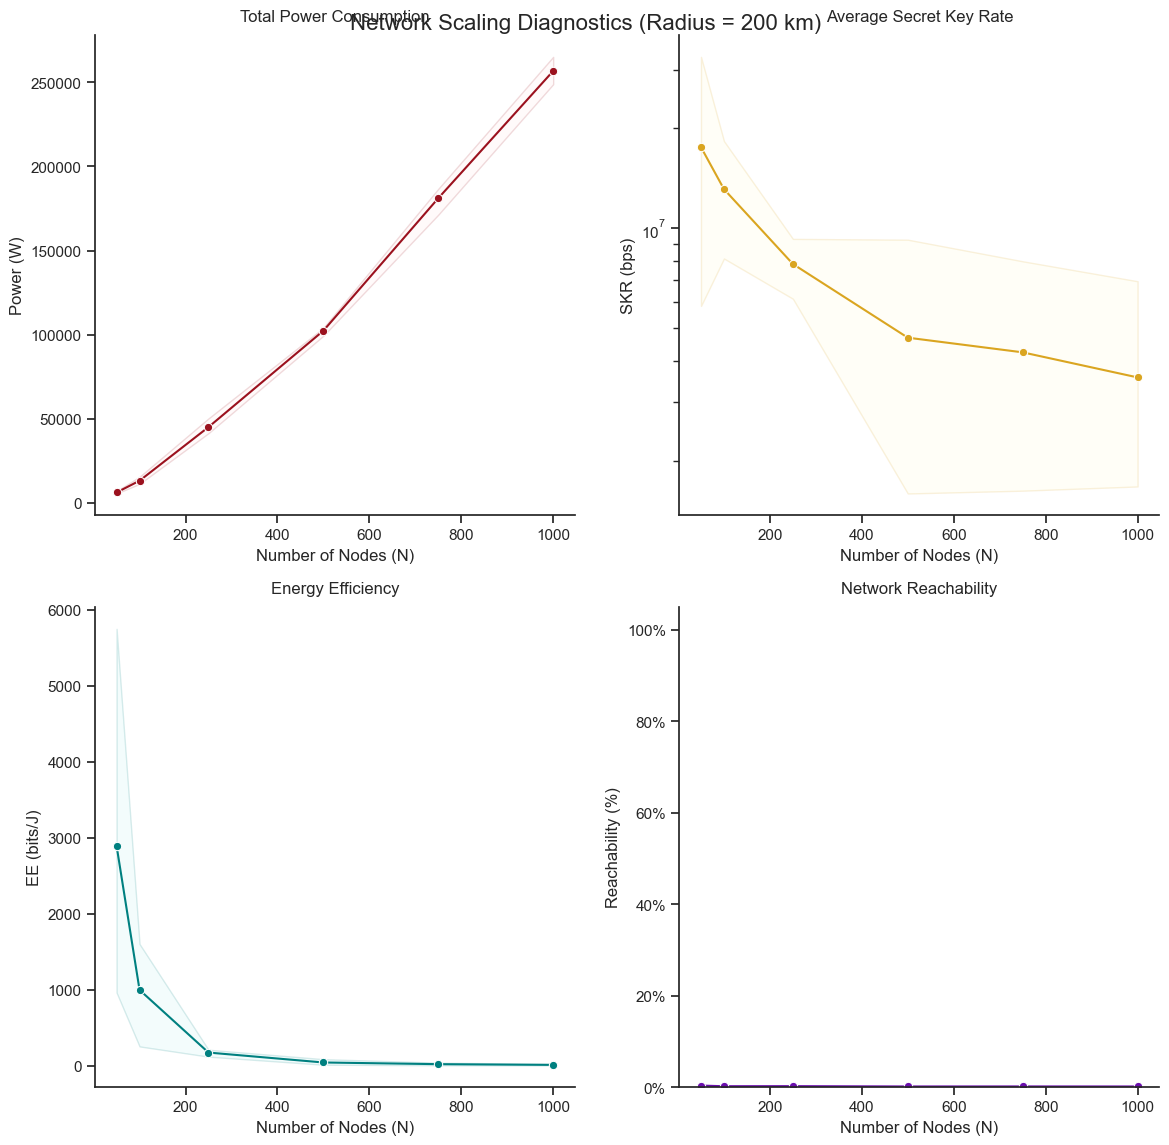

In [6]:
# Sweeping N from 50 up to 1000
N_values = [50, 100, 250, 500, 750, 1000]
fixed_radius = 200 # Constant area
scaling_data = []

print("Running Node Scaling Simulations (Constant Area)...")
for n_val in N_values:
    for _ in range(3): # 3 iterations per N to get a variance band

        # Make sure to unpack the new 'reach' variable!
        _, _, _, pwr, skr, ee, reach = network_energy_efficiency(num_runs=1, N=n_val, radius=fixed_radius, type = 'CV')

        # Save them all to the dictionary (converting reach to a percentage)
        scaling_data.append({
            'N': n_val,
            'Power (W)': pwr,
            'SKR (bps)': skr,
            'EE (bits/J)': ee,
            'Reachability (%)': reach * 100
        })

df_scaling = pd.DataFrame(scaling_data)

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten() # Flattens the 2x2 array into a 1D list so we can index it 0-3

# Plot 1 (Top Left): Power (The Denominator)
sns.lineplot(data=df_scaling, x='N', y='Power (W)', color='#9B111E', ax=axes[0], marker='o', err_kws={'alpha': 0.15, 'facecolor': 'mistyrose'})
axes[0].set_title('Total Power Consumption', fontsize=12, pad=10)
axes[0].set_xlabel('Number of Nodes (N)')

# Plot 2 (Top Right): SKR (The Numerator)
sns.lineplot(data=df_scaling, x='N', y='SKR (bps)', color='#DAA520', ax=axes[1], marker='o', err_kws={'alpha': 0.15, 'facecolor': 'lemonchiffon'})
axes[1].set_title('Average Secret Key Rate', fontsize=12, pad=10)
axes[1].set_xlabel('Number of Nodes (N)')
axes[1].set_yscale('log') # Log scale to clearly see the crash

# Plot 3 (Bottom Left): EE (The Final Ratio)
sns.lineplot(data=df_scaling, x='N', y='EE (bits/J)', color='#008080', ax=axes[2], marker='o', err_kws={'alpha': 0.15, 'facecolor': 'paleturquoise'})
axes[2].set_title('Energy Efficiency', fontsize=12, pad=10)
axes[2].set_xlabel('Number of Nodes (N)')

# Plot 4 (Bottom Right): Reachability
sns.lineplot(data=df_scaling, x='N', y='Reachability (%)', color='#6A0DAD', ax=axes[3], marker='o', err_kws={'alpha': 0.15, 'facecolor': 'thistle'})
axes[3].set_title('Network Reachability', fontsize=12, pad=10)
axes[3].set_xlabel('Number of Nodes (N)')
axes[3].set_ylim(0, 105) # Force Y-axis to go from 0% to a little over 100%
axes[3].yaxis.set_major_formatter(mtick.PercentFormatter()) # Add the '%' sign to the axis labels

# Format all boxes to be perfectly square
for ax in axes:
    ax.set_box_aspect(1)

plt.suptitle(f'Network Scaling Diagnostics (Radius = {fixed_radius} km)', fontsize=16, y=0.95)
plt.tight_layout()
plt.savefig('plots/4_scaling_diagnostics_2x2.pdf', bbox_inches='tight')
plt.show()

Running Node Scaling Simulations for All Architectures...

--- Simulating Architecture: CV ---

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 363,900 W | SKR: 38,192,990.13 bps | EE: 104.95457307 bits/J | REACH: 100.00 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 363,900 W | Avg SKR: 38,192,990.13 bps | Avg EE: 104.95457307 bits/J | AVG REACH: 100.00 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 346,311 W | SKR: 57,646,879.15 bps | EE: 166.46004814 bits/J | REACH: 81.55 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 346,311 W | Avg SKR: 57,646,879.15 bps | Avg EE: 166.46004814 bits/J | AVG REACH: 81.55 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 311,459 W | SKR: 26,727,485.52 bps | EE: 85.81381664 bits/J | REACH: 65.52 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 311,459 W | Avg SKR: 26,727,485.52 bps | Avg EE: 85.81381664 bits/J | AVG REACH: 65.52 %

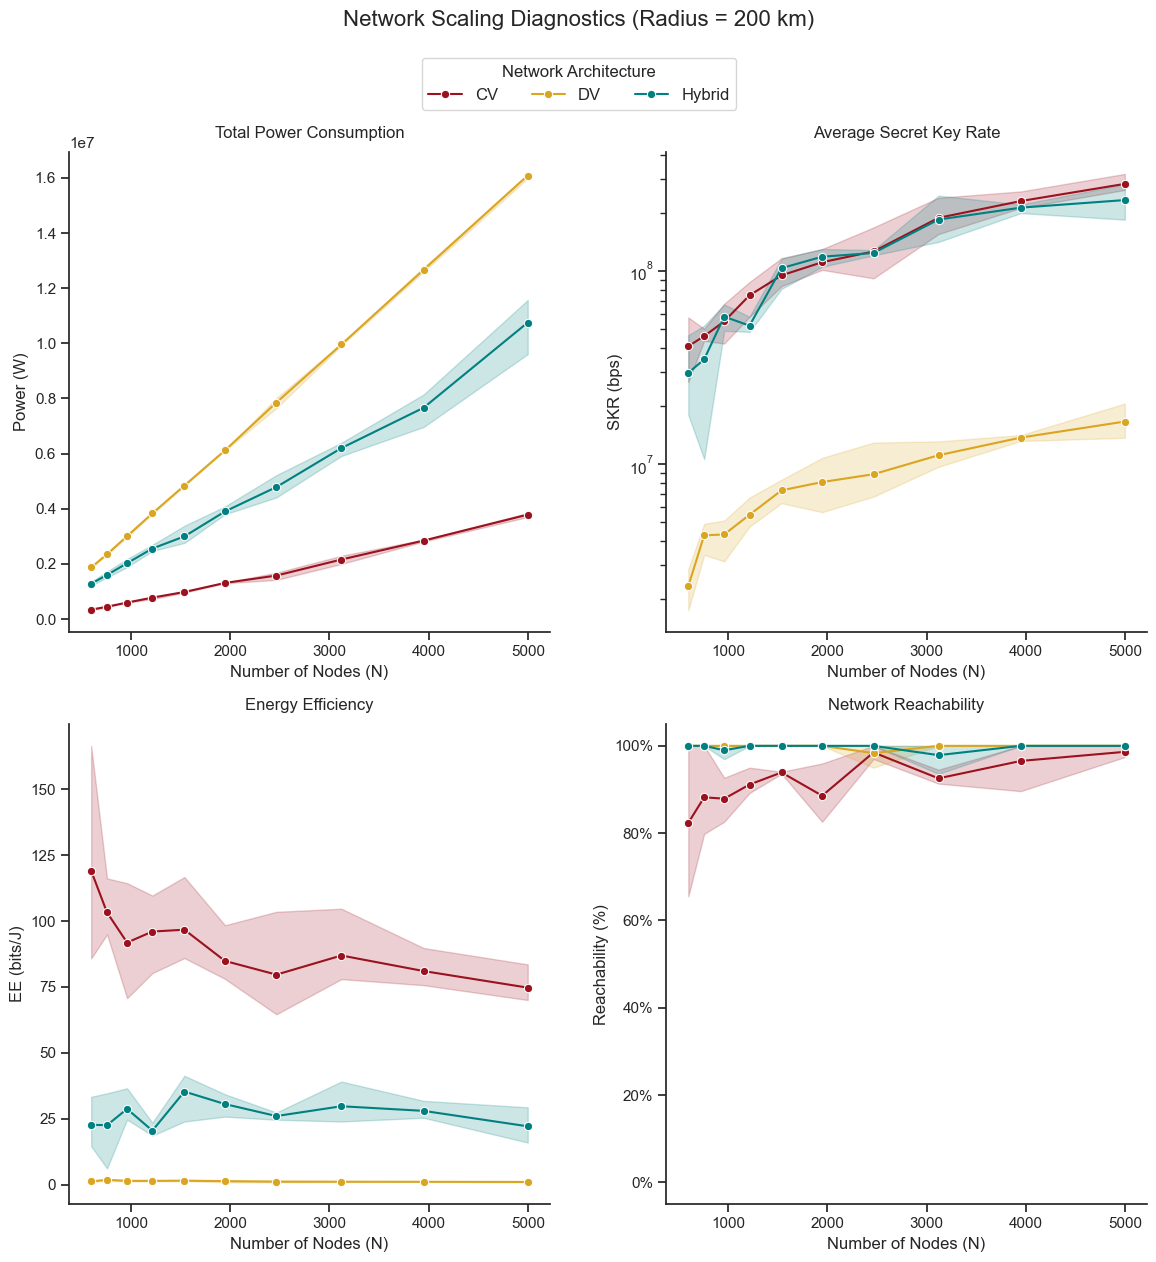

In [4]:
# Sweeping N from 50 up to 1000
N_values = np.logspace(np.log10(600), np.log10(5000), num=10, dtype=int)
fixed_radius = 200 # Constant area
architectures = ['CV', 'DV', 'hybrid'] # Loop through all three!
scaling_data = []

print("Running Node Scaling Simulations for All Architectures...")
for net_type in architectures:
    print(f"\n--- Simulating Architecture: {net_type.upper()} ---")
    for n_val in N_values:
        for _ in range(3): # 3 iterations per N to get a variance band

            # Pass the 'net_type' to the type argument!
            _, _, _, pwr, skr, ee, reach = network_energy_efficiency(
                num_runs=1, N=n_val, radius=fixed_radius, type=net_type
            )

            # Format the name nicely for the legend
            display_name = net_type.capitalize() if net_type == 'hybrid' else net_type

            # Save them all to the dictionary, adding the Architecture label
            scaling_data.append({
                'Architecture': display_name,
                'N': n_val,
                'Power (W)': pwr,
                'SKR (bps)': skr,
                'EE (bits/J)': ee,
                'Reachability (%)': reach * 100
            })

df_scaling = pd.DataFrame(scaling_data)

# Create a custom palette keeping the jewel-tone aesthetic
# CV = Ruby Red, DV = Goldenrod, Hybrid = Deep Teal
arch_palette = {
    'CV': '#9B111E',
    'DV': '#DAA520',
    'Hybrid': '#008080'
}

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

# Plot 1 (Top Left): Power
# Note: err_kws facecolor is removed because seaborn automatically matches the variance band to the line color!
sns.lineplot(data=df_scaling, x='N', y='Power (W)', hue='Architecture', palette=arch_palette,
             ax=axes[0], marker='o', legend=False)
axes[0].set_title('Total Power Consumption', fontsize=12, pad=10)
axes[0].set_xlabel('Number of Nodes (N)')

# Plot 2 (Top Right): SKR
sns.lineplot(data=df_scaling, x='N', y='SKR (bps)', hue='Architecture', palette=arch_palette,
             ax=axes[1], marker='o', legend=False)
axes[1].set_title('Average Secret Key Rate', fontsize=12, pad=10)
axes[1].set_xlabel('Number of Nodes (N)')
axes[1].set_yscale('log')

# Plot 3 (Bottom Left): EE
sns.lineplot(data=df_scaling, x='N', y='EE (bits/J)', hue='Architecture', palette=arch_palette,
             ax=axes[2], marker='o', legend=False)
axes[2].set_title('Energy Efficiency', fontsize=12, pad=10)
axes[2].set_xlabel('Number of Nodes (N)')

# Plot 4 (Bottom Right): Reachability
# We turn the legend ON here just to extract the handles, then hide it
sns.lineplot(data=df_scaling, x='N', y='Reachability (%)', hue='Architecture', palette=arch_palette,
             ax=axes[3], marker='o', legend=True)
axes[3].set_title('Network Reachability', fontsize=12, pad=10)
axes[3].set_xlabel('Number of Nodes (N)')
axes[3].set_ylim(-5, 105)
axes[3].yaxis.set_major_formatter(mtick.PercentFormatter())

# Format all boxes to be perfectly square
for ax in axes:
    ax.set_box_aspect(1)

# Extract the legend from the 4th plot and move it to the very top of the figure
handles, labels = axes[3].get_legend_handles_labels()
axes[3].get_legend().remove() # Remove it from the individual subplot
fig.legend(handles, labels, title='Network Architecture', loc='lower center',
           bbox_to_anchor=(0.5, 0.96), ncol=3, fontsize=12, title_fontsize=12)

# Adjust the title slightly higher to make room for the new master legend
plt.suptitle(f'Network Scaling Diagnostics (Radius = {fixed_radius} km)', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('plots/4_scaling_diagnostics_2x2_comparison.pdf', bbox_inches='tight')
plt.show()

Running Radius Scaling Simulations (Constant N=1000) for All Architectures...

--- Simulating Architecture: CV ---

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 1,068,176 W | SKR: 1,667,945,434.28 bps | EE: 1,561.48992195 bits/J | REACH: 100.00 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 1,068,176 W | Avg SKR: 1,667,945,434.28 bps | Avg EE: 1,561.48992195 bits/J | AVG REACH: 100.00 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 887,710 W | SKR: 1,452,772,001.10 bps | EE: 1,636.53896104 bits/J | REACH: 100.00 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 887,710 W | Avg SKR: 1,452,772,001.10 bps | Avg EE: 1,636.53896104 bits/J | AVG REACH: 100.00 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 790,245 W | SKR: 1,478,878,398.86 bps | EE: 1,871.41807053 bits/J | REACH: 100.00 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 790,245 W | Avg SKR: 1,478,878,398.

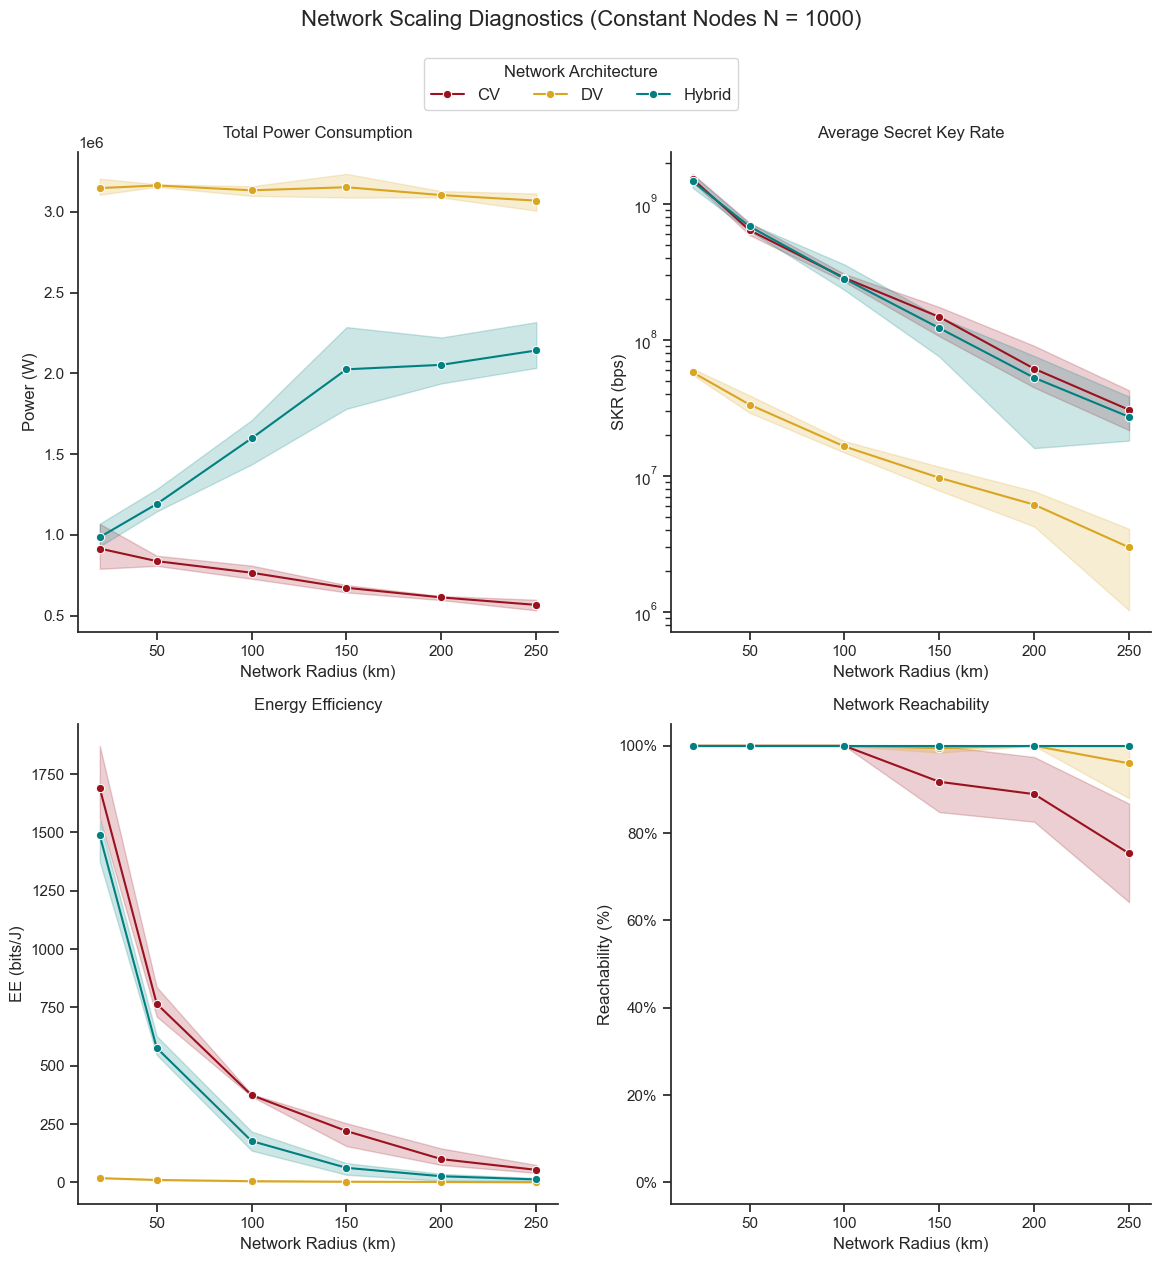

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Sweeping Radius from a dense city to a sparse country
fixed_N = 1000
# Sweeping safely below the 269 km limit
R_values = [20, 50, 100, 150, 200, 250]
architectures = ['CV', 'DV', 'hybrid'] # Loop through all three!
scaling_data_R = []

print(f"Running Radius Scaling Simulations (Constant N={fixed_N}) for All Architectures...")
for net_type in architectures:
    print(f"\n--- Simulating Architecture: {net_type.upper()} ---")
    for r_val in R_values:
        for _ in range(3): # 3 iterations per R to get a variance band

            # Make sure to unpack the new 'reach' variable and pass the architecture type!
            _, _, _, pwr, skr, ee, reach = network_energy_efficiency(
                num_runs=1, N=fixed_N, radius=r_val, type=net_type
            )

            # Format the name nicely for the legend
            display_name = net_type.capitalize() if net_type == 'hybrid' else net_type

            # Save them all to the dictionary, adding the Architecture label
            scaling_data_R.append({
                'Architecture': display_name,
                'Radius (km)': r_val,
                'Power (W)': pwr,
                'SKR (bps)': skr,
                'EE (bits/J)': ee,
                'Reachability (%)': reach * 100
            })

df_scaling_R = pd.DataFrame(scaling_data_R)

# Create a custom palette keeping the jewel-tone aesthetic
arch_palette = {
    'CV': '#9B111E',
    'DV': '#DAA520',
    'Hybrid': '#008080'
}

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

# Plot 1 (Top Left): Power
sns.lineplot(data=df_scaling_R, x='Radius (km)', y='Power (W)', hue='Architecture', palette=arch_palette,
             ax=axes[0], marker='o', legend=False)
axes[0].set_title('Total Power Consumption', fontsize=12, pad=10)
axes[0].set_xlabel('Network Radius (km)')

# Plot 2 (Top Right): SKR
sns.lineplot(data=df_scaling_R, x='Radius (km)', y='SKR (bps)', hue='Architecture', palette=arch_palette,
             ax=axes[1], marker='o', legend=False)
axes[1].set_title('Average Secret Key Rate', fontsize=12, pad=10)
axes[1].set_xlabel('Network Radius (km)')
axes[1].set_yscale('log')

# Plot 3 (Bottom Left): EE
sns.lineplot(data=df_scaling_R, x='Radius (km)', y='EE (bits/J)', hue='Architecture', palette=arch_palette,
             ax=axes[2], marker='o', legend=False)
axes[2].set_title('Energy Efficiency', fontsize=12, pad=10)
axes[2].set_xlabel('Network Radius (km)')

# Plot 4 (Bottom Right): Reachability
sns.lineplot(data=df_scaling_R, x='Radius (km)', y='Reachability (%)', hue='Architecture', palette=arch_palette,
             ax=axes[3], marker='o', legend=True)
axes[3].set_title('Network Reachability', fontsize=12, pad=10)
axes[3].set_xlabel('Network Radius (km)')
axes[3].set_ylim(-5, 105)
axes[3].yaxis.set_major_formatter(mtick.PercentFormatter())

# Format all boxes to be perfectly square
for ax in axes:
    ax.set_box_aspect(1)

# Extract the legend and move it to the very top of the figure
handles, labels = axes[3].get_legend_handles_labels()
axes[3].get_legend().remove()
fig.legend(handles, labels, title='Network Architecture', loc='lower center',
           bbox_to_anchor=(0.5, 0.96), ncol=3, fontsize=12, title_fontsize=12)

# Adjust the title slightly higher to make room for the master legend
plt.suptitle(f'Network Scaling Diagnostics (Constant Nodes N = {fixed_N})', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('plots/7_scaling_R_diagnostics_2x2_comparison.pdf', bbox_inches='tight')
plt.show()

 ## Plot 5: Metrics vs Density

Running Density Simulations for N=1000...


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

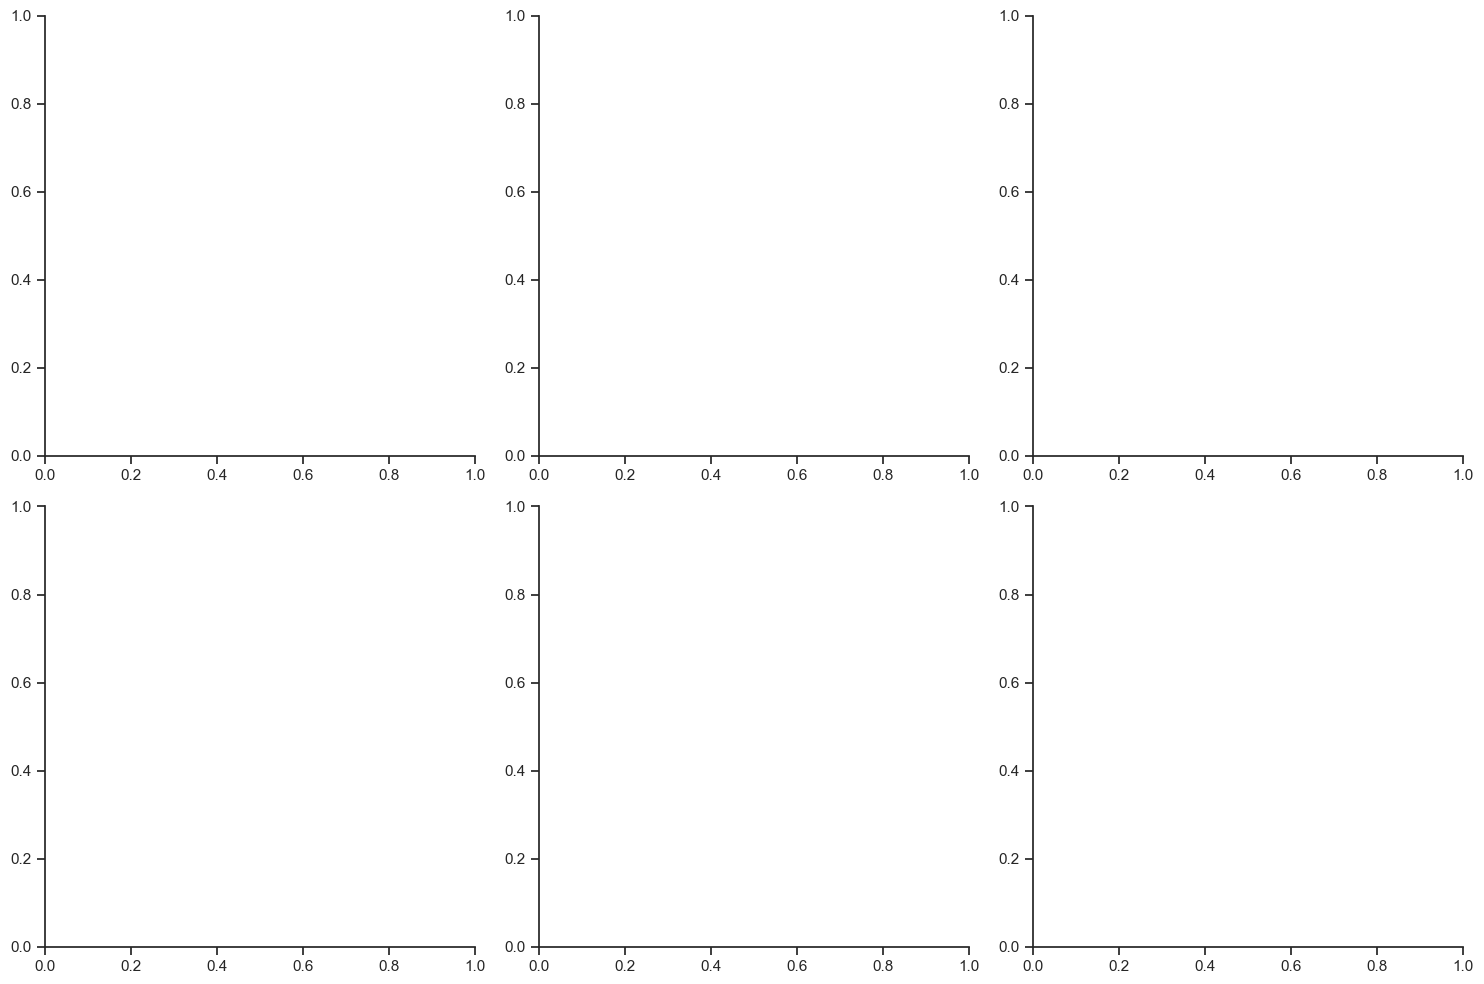

In [7]:
N_val = 1000
# Generate 10 logarithmic density points exactly like the Mariani paper
rhos = np.logspace(np.log10(1.5e-3), -1, 10)
density_data = []

print(f"Running Density Simulations for N={N_val}...")
for rho in rhos:
    # Calculate the physical radius required to achieve this density
    r_real = np.sqrt(N_val / (4 * np.pi * rho))

    for _ in range(3):  # 3 runs per density step
        A, Dists = S2_graph_definite_N(N_val, 2.6261, 0.0233, return_coords=False)
        W, edge_CV, edge_DV = np.zeros_like(A), np.zeros_like(A), np.zeros_like(A)

        for i in range(N_val):
            for j in range(i):
                if A[i, j] == 1:
                    dij = r_real * Dists[i, j]
                    idx_d = np.argmin(abs(dij - d_set))
                    h_rate = keyrates[idx_d]
                    if dij < d_c_DV and h_rate > rate_min:
                        W[i, j] = W[j, i] = h_rate ** -1
                        if dij >= d_hybrid:
                            edge_DV[i, j] = edge_DV[j, i] = True
                        else:
                            edge_CV[i, j] = edge_CV[j, i] = True

        G_d = nx.from_numpy_array(W)

        _, pwr = power_cost(G_d, edge_CV, edge_DV, include_true_dsp_cost=True)
        skr = avg_SKR(G_d)  # Uses the full Dijkstra on the giant component
        ee = skr / pwr if pwr > 0 else 0

        classes = [classifiying_node(G_d, n, edge_CV, edge_DV) for n in G_d.nodes()]

        density_data.append({
            'Density (km^-2)': rho, 'Power (W)': pwr, 'SKR (bps)': skr, 'EE (bits/J)': ee,
            'CV Nodes': classes.count('CV'), 'DV Nodes': classes.count('DV'), 'Hybrid Nodes': classes.count('hybrid')
        })

df_dense = pd.DataFrame(density_data)

# --- PLOT 6: MAIN TILE GRAPH ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sns.lineplot(data=df_dense, x='Density (km^-2)', y='EE (bits/J)', ax=axes[0], color='#008080')
sns.lineplot(data=df_dense, x='Density (km^-2)', y='SKR (bps)', ax=axes[1], color='#CC5500')
sns.lineplot(data=df_dense, x='Density (km^-2)', y='Power (W)', ax=axes[2], color='#DAA520')

sns.lineplot(data=df_dense, x='Density (km^-2)', y='CV Nodes', ax=axes[3], color=COLOR_CV)
sns.lineplot(data=df_dense, x='Density (km^-2)', y='DV Nodes', ax=axes[4], color=COLOR_DV)
sns.lineplot(data=df_dense, x='Density (km^-2)', y='Hybrid Nodes', ax=axes[5], color=COLOR_HYBRID)

for i, ax in enumerate(axes):
    ax.set_box_aspect(1)
    # Set the x-axis to logarithmic to match the academic papers
    ax.set_xscale('log')

    if i > 2:
        # Scale the node counts to the new N_val limit
        ax.set_ylim(0, N_val)

plt.suptitle(f'Network Metrics vs. Density ($N={N_val}$) with DSP', fontsize=18)
plt.savefig('plots/5_metrics_vs_density.pdf', bbox_inches='tight')
plt.show()

Running Density Simulations for N=1000...


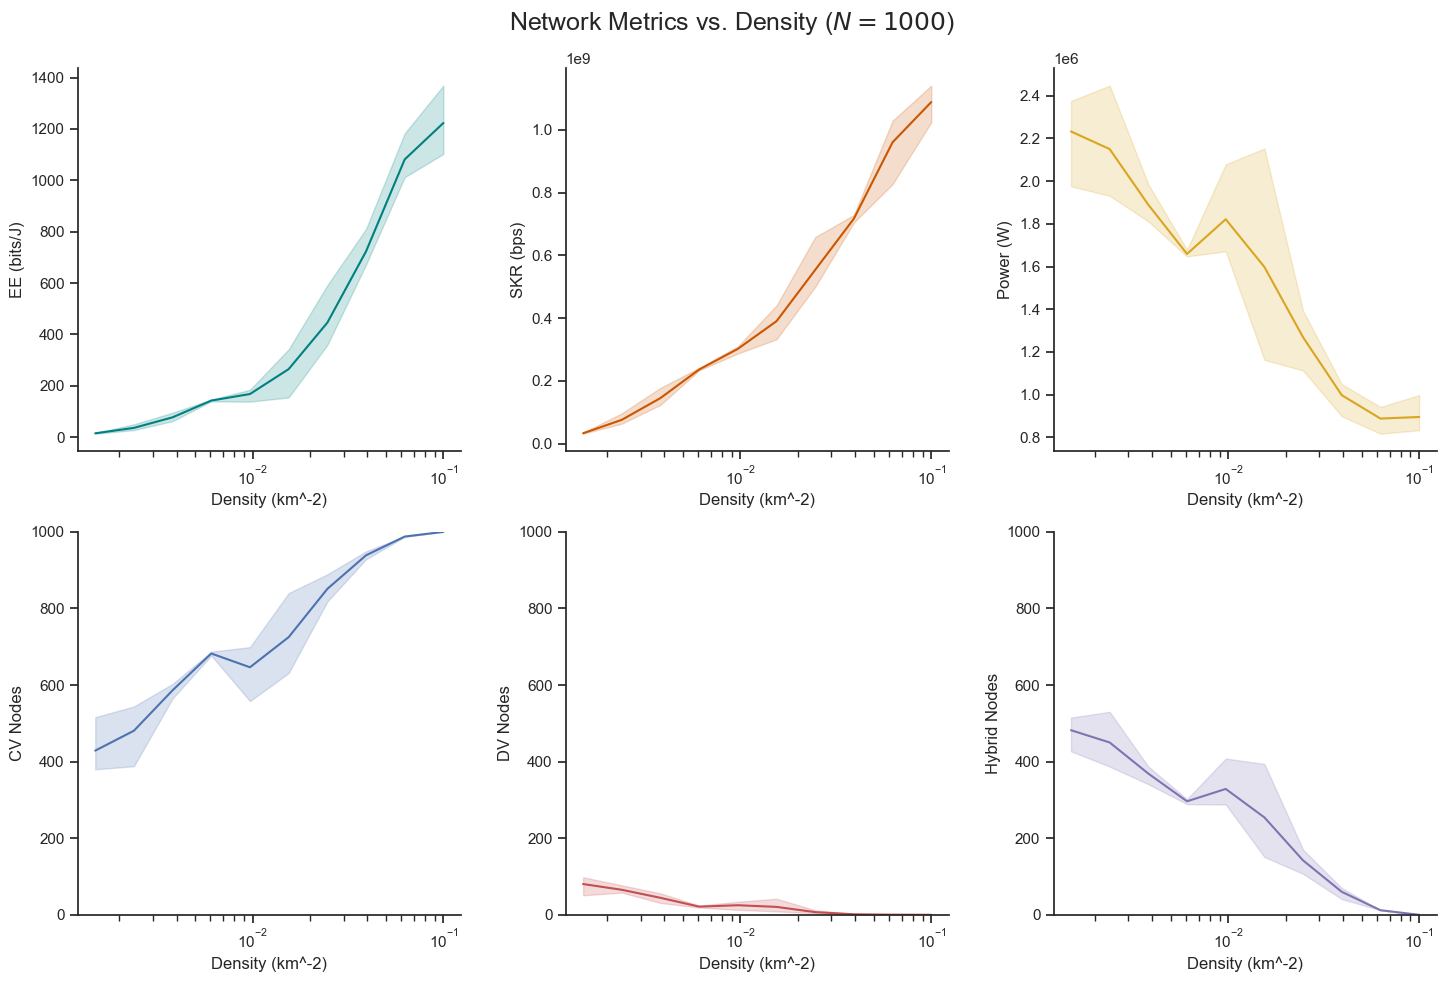

In [8]:
N_val = 1000
# Generate 10 logarithmic density points exactly like the Mariani paper
rhos = np.logspace(np.log10(1.5e-3), -1, 10)
density_data = []

print(f"Running Density Simulations for N={N_val}...")
for rho in rhos:
    # Calculate the physical radius required to achieve this density
    r_real = np.sqrt(N_val / (4 * np.pi * rho))

    for _ in range(3): # 3 runs per density step
        A, Dists = S2_graph_definite_N(N_val, 2.6261, 0.0233, return_coords=False)
        W, edge_CV, edge_DV = np.zeros_like(A), np.zeros_like(A), np.zeros_like(A)

        for i in range(N_val):
            for j in range(i):
                if A[i, j] == 1:
                    dij = r_real * Dists[i, j]
                    idx_d = np.argmin(abs(dij - d_set))
                    h_rate = keyrates[idx_d]
                    if dij < d_c_DV and h_rate > rate_min:
                        W[i, j] = W[j, i] = h_rate ** -1
                        if dij >= d_hybrid: edge_DV[i, j] = edge_DV[j, i] = True
                        else: edge_CV[i, j] = edge_CV[j, i] = True

        G_d = nx.from_numpy_array(W)

        _, pwr = power_cost(G_d, edge_CV, edge_DV, include_true_dsp_cost=False)
        skr, _ = avg_SKR(G_d) # Uses the full Dijkstra on the giant component
        ee = skr / pwr if pwr > 0 else 0

        classes = [classifiying_node(G_d, n, edge_CV, edge_DV) for n in G_d.nodes()]

        density_data.append({
            'Density (km^-2)': rho, 'Power (W)': pwr, 'SKR (bps)': skr, 'EE (bits/J)': ee,
            'CV Nodes': classes.count('CV'), 'DV Nodes': classes.count('DV'), 'Hybrid Nodes': classes.count('hybrid')
        })

df_dense = pd.DataFrame(density_data)

# --- PLOT 6: MAIN TILE GRAPH ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sns.lineplot(data=df_dense, x='Density (km^-2)', y='EE (bits/J)', ax=axes[0], color='#008080')
sns.lineplot(data=df_dense, x='Density (km^-2)', y='SKR (bps)', ax=axes[1], color='#CC5500')
sns.lineplot(data=df_dense, x='Density (km^-2)', y='Power (W)', ax=axes[2], color='#DAA520')

sns.lineplot(data=df_dense, x='Density (km^-2)', y='CV Nodes', ax=axes[3], color=COLOR_CV)
sns.lineplot(data=df_dense, x='Density (km^-2)', y='DV Nodes', ax=axes[4], color=COLOR_DV)
sns.lineplot(data=df_dense, x='Density (km^-2)', y='Hybrid Nodes', ax=axes[5], color=COLOR_HYBRID)

for i, ax in enumerate(axes):
    ax.set_box_aspect(1)
    # Set the x-axis to logarithmic to match the academic papers
    ax.set_xscale('log')

    if i > 2:
        # Scale the node counts to the new N_val limit
        ax.set_ylim(0, N_val)

plt.suptitle(f'Network Metrics vs. Density ($N={N_val}$)', fontsize=18)
plt.savefig('plots/5_metrics_vs_density_wo_dsp.pdf', bbox_inches='tight')
plt.show()

Running Density Scaling Simulations (Constant N=1000) for All Architectures...

--- Simulating Architecture: CV ---

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 606,365 W | SKR: 31,798,033.32 bps | EE: 52.44045138 bits/J | REACH: 71.16 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 606,365 W | Avg SKR: 31,798,033.32 bps | Avg EE: 52.44045138 bits/J | AVG REACH: 71.16 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 527,728 W | SKR: 22,885,802.94 bps | EE: 43.36666415 bits/J | REACH: 73.93 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 527,728 W | Avg SKR: 22,885,802.94 bps | Avg EE: 43.36666415 bits/J | AVG REACH: 73.93 %

 TOPOLOGY DIAGNOSTIC: Testing 1 Unique Network Layouts 
Graph Layout 1 -> Power: 575,289 W | SKR: 30,055,019.58 bps | EE: 52.24335947 bits/J | REACH: 77.24 %

--- AVERAGE RESULTS ACROSS ALL RUNS ---
Avg Power: 575,289 W | Avg SKR: 30,055,019.58 bps | Avg EE: 52.24335947 bits/J | AVG

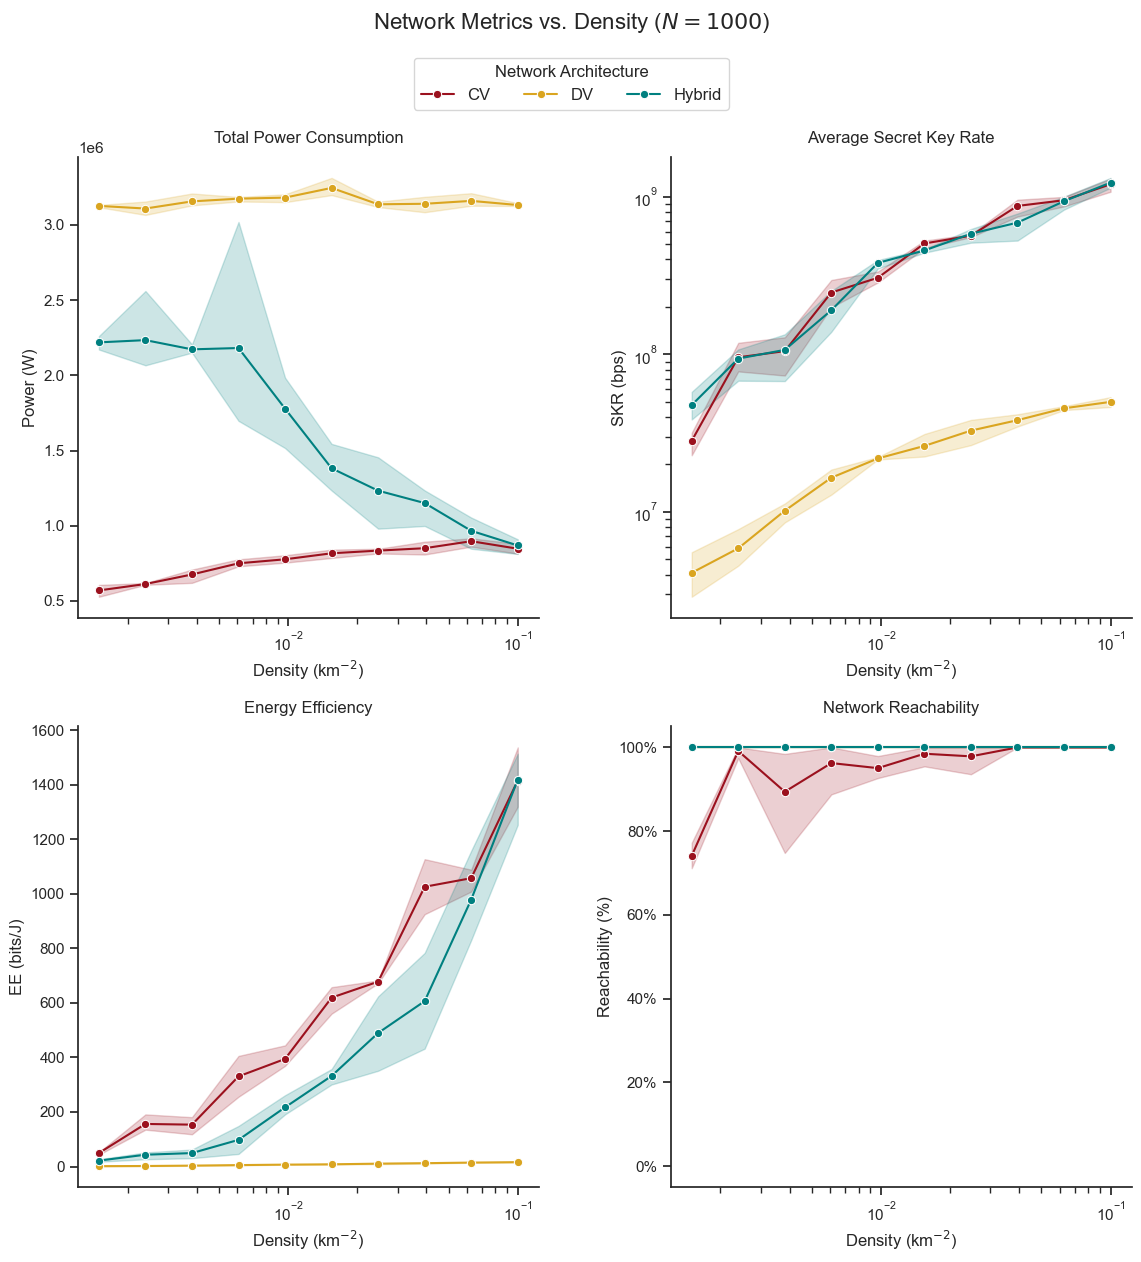

In [6]:
N_val = 1000
# Generate 10 logarithmic density points exactly like the Mariani paper
rhos = np.logspace(np.log10(1.5e-3), -1, 10)
architectures = ['CV', 'DV', 'hybrid'] # Loop through all three!
density_data = []

print(f"Running Density Scaling Simulations (Constant N={N_val}) for All Architectures...")
for net_type in architectures:
    print(f"\n--- Simulating Architecture: {net_type.upper()} ---")
    for rho in rhos:
        # Calculate the physical radius required to achieve this density
        r_real = np.sqrt(N_val / (4 * np.pi * rho))

        for _ in range(3): # 3 runs per density step

            # Call your robust function that handles pruning, routing, and reachability!
            _, _, _, pwr, skr, ee, reach = network_energy_efficiency(
                num_runs=1, N=N_val, radius=r_real, type=net_type
            )

            # Format the name nicely for the legend
            display_name = net_type.capitalize() if net_type == 'hybrid' else net_type

            density_data.append({
                'Architecture': display_name,
                'Density (km^-2)': rho,
                'Power (W)': pwr,
                'SKR (bps)': skr,
                'EE (bits/J)': ee,
                'Reachability (%)': reach * 100
            })

df_dense = pd.DataFrame(density_data)

# Create a custom palette keeping the jewel-tone aesthetic
arch_palette = {
    'CV': '#9B111E',
    'DV': '#DAA520',
    'Hybrid': '#008080'
}

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

# Plot 1 (Top Left): Power
sns.lineplot(data=df_dense, x='Density (km^-2)', y='Power (W)', hue='Architecture', palette=arch_palette,
             ax=axes[0], marker='o', legend=False)
axes[0].set_title('Total Power Consumption', fontsize=12, pad=10)
axes[0].set_xlabel('Density (km$^{-2}$)')
axes[0].set_xscale('log') # IMPORTANT: Log scale for density!

# Plot 2 (Top Right): SKR
sns.lineplot(data=df_dense, x='Density (km^-2)', y='SKR (bps)', hue='Architecture', palette=arch_palette,
             ax=axes[1], marker='o', legend=False)
axes[1].set_title('Average Secret Key Rate', fontsize=12, pad=10)
axes[1].set_xlabel('Density (km$^{-2}$)')
axes[1].set_xscale('log')
axes[1].set_yscale('log') # Log scale for Y (rates drop exponentially)

# Plot 3 (Bottom Left): EE
sns.lineplot(data=df_dense, x='Density (km^-2)', y='EE (bits/J)', hue='Architecture', palette=arch_palette,
             ax=axes[2], marker='o', legend=False)
axes[2].set_title('Energy Efficiency', fontsize=12, pad=10)
axes[2].set_xlabel('Density (km$^{-2}$)')
axes[2].set_xscale('log')

# Plot 4 (Bottom Right): Reachability
sns.lineplot(data=df_dense, x='Density (km^-2)', y='Reachability (%)', hue='Architecture', palette=arch_palette,
             ax=axes[3], marker='o', legend=True)
axes[3].set_title('Network Reachability', fontsize=12, pad=10)
axes[3].set_xlabel('Density (km$^{-2}$)')
axes[3].set_xscale('log')
axes[3].set_ylim(-5, 105)
axes[3].yaxis.set_major_formatter(mtick.PercentFormatter())

# Format all boxes to be perfectly square
for ax in axes:
    ax.set_box_aspect(1)

# Extract the legend and move it to the very top of the figure
handles, labels = axes[3].get_legend_handles_labels()
axes[3].get_legend().remove()
fig.legend(handles, labels, title='Network Architecture', loc='lower center',
           bbox_to_anchor=(0.5, 0.96), ncol=3, fontsize=12, title_fontsize=12)

# Adjust the title slightly higher to make room for the master legend
plt.suptitle(f'Network Metrics vs. Density ($N={N_val}$)', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('plots/5_metrics_vs_density_comparison.pdf', bbox_inches='tight')
plt.show()

Running Percolation Diagnostics for N=1000 across 5 topologies...
  Processing topology 1/5...
  Processing topology 2/5...
  Processing topology 3/5...
  Processing topology 4/5...
  Processing topology 5/5...


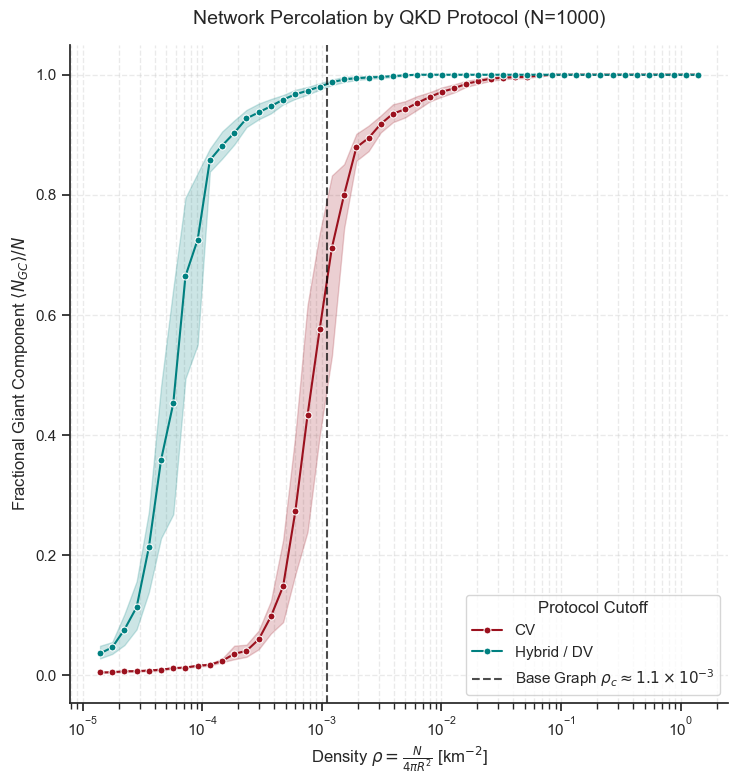

In [7]:
# --- 1. SIMULATION PARAMETERS ---
N_val = 1000
num_runs = 5 # Number of topologies to generate (Seaborn will use this to draw variance bands)

# Sweep density from 10^-4 to 10^-1 (using 30 points for a smooth curve)
rhos = 0.14*10**np.linspace(-4.,1.,50)
radii = np.sqrt(N_val / (4 * np.pi * rhos))

percolation_data = []

print(f"Running Percolation Diagnostics for N={N_val} across {num_runs} topologies...")

# --- 2. DATA GENERATION ---
for run in range(num_runs):
    print(f"  Processing topology {run + 1}/{num_runs}...")

    # Generate the base complex network
    A, Dists = S2_graph_definite_N(N_val, beta, mu, return_coords=False)
    valid_edges = (A == 1)

    for r_idx, radius in enumerate(radii):
        rho = rhos[r_idx]
        Physical_Dists = radius * Dists

        # Prune edges based on the physical cutoff of the hardware
        # Hybrid and DV share the exact same physical cutoff distance (d_c_DV)
        A_CV = np.where(valid_edges & (Physical_Dists < d_c_CV), 1, 0)
        A_Hybrid_DV = np.where(valid_edges & (Physical_Dists < d_c_DV), 1, 0)

        # Create graphs
        G_CV = nx.from_numpy_array(A_CV)
        G_Hybrid_DV = nx.from_numpy_array(A_Hybrid_DV)

        # Calculate fractional giant component size
        comp_CV = max(nx.connected_components(G_CV), key=len) if G_CV.nodes else []
        comp_Hybrid_DV = max(nx.connected_components(G_Hybrid_DV), key=len) if G_Hybrid_DV.nodes else []

        frac_CV = len(comp_CV) / N_val
        frac_Hybrid_DV = len(comp_Hybrid_DV) / N_val

        # Append to our dataframe list
        percolation_data.append({'Architecture': 'CV', 'Density': rho, 'Fractional GC': frac_CV})
        percolation_data.append({'Architecture': 'Hybrid / DV', 'Density': rho, 'Fractional GC': frac_Hybrid_DV})

df_perc = pd.DataFrame(percolation_data)

# --- 3. PLOTTING (MATCHING YOUR AESTHETIC) ---
# Use your exact jewel-tone palette
arch_palette = {
    'CV': '#9B111E',           # Ruby Red
    'Hybrid / DV': '#008080'   # Deep Teal (Using Hybrid's color since it shares DV's reach)
}

fig, ax = plt.subplots(figsize=(8, 8)) # Square aspect ratio

# Seaborn lineplot (automatically handles the averaging and variance bands across the 5 runs)
sns.lineplot(data=df_perc, x='Density', y='Fractional GC', hue='Architecture',
             palette=arch_palette, ax=ax, marker='o', markersize=5)

# Formatting the axes
ax.set_xscale('log')
ax.set_xlabel(r'Density $\rho = \frac{N}{4\pi R^2}$ [km$^{-2}$]', fontsize=12)
ax.set_ylabel(r'Fractional Giant Component $\langle N_{GC} \rangle / N$', fontsize=12)
ax.set_title(f'Network Percolation by QKD Protocol (N={N_val})', fontsize=14, pad=15)

# Add the theoretical baseline from the Mariani paper
ax.axvline(x=1.1e-3, color='black', linestyle='--', alpha=0.7,
           label=r'Base Graph $\rho_c \approx 1.1 \times 10^{-3}$')

# Force the box to be perfectly square to match your 2x2 grid aesthetic
ax.set_box_aspect(1)

# Clean up the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title='Protocol Cutoff', loc='lower right', fontsize=11)

plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()

# Save and show
plt.savefig('plots/Percolation_Density_Comparison.pdf', bbox_inches='tight')
plt.show()